# Practice Data Analysis in Real-World Scenario

I use Bundesliga data from the season 2025/2026 from http://www.football-data.co.uk/ (downloaded from https://datahub.io/football/german-bundesliga)

In [73]:
import pandas as pd

In [74]:
df_raw = pd.read_csv("data/raw/season-2526.csv")
df = df_raw.copy()
df.to_excel("data/processed/season-2526.xlsx")

### Project Director Role
- Does scoring first-half goals predict winning beyond simply being the stronger shooting team?
- Are shots on target more informative about goals than total shots?
- Do red cards actually reduce a team's probability of winning?

### Project Manager Role
*Are shots on target more informative about goals than total shots?*

A match has two observations, one for each team. 
The relevant outcome is goals, not win. 
The relevant variables are HomeTeam resp. AwayTeam, HS (home shots) resp. AS (away shots), HST (home shots on target) resp. AST (away shots on target) and FTHG (full time home goals) resp. FTAG (full time away goals). 

It may be possible to control for home advantage or to look at more than one season.

### Data Analyst Role
- I will clean the data in the sense of tidy data. 
    - Create two dataframes, one for the home teams and one for the away teams with a corresponding variable "venue" with categories "home" and "away".
    - Create a variable "team": For home df take HomeTeam, for away df take AwayTeam. For completeness I will create a variable "opponent" for the respective other team.
    - Check for missing values using .isna() and most likely .dropna().
    - Finally concatenate the two df using pd.concat()
- I will explore distributions of goals, shots and shots_on_target using .describe() and visualisations
- I will explore relationships goals vs. shots, goals vs. shots on target using scatterplots, maybe correlations with .corr()

### Programmer/Analyst Role

**Tidy data**

In [75]:
home = df[["HomeTeam", "AwayTeam", "HS", "HST", "FTHG"]]
away = df[["AwayTeam", "HomeTeam", "AS", "AST", "FTAG"]]

home.columns = ["team", "opponent", "shots", "shots_on_target", "goals"]
away.columns = ["team", "opponent", "shots", "shots_on_target", "goals"]

home["venue"] = "home"
away["venue"] = "away"

shots = pd.concat([home, away])
shots

,team,opponent,shots,shots_on_target,goals,venue
0,Bayern Munich,RB Leipzig,19,10,6,home
1,Ein Frankfurt,Werder Bremen,18,5,4,home
2,Freiburg,Augsburg,16,4,1,home
3,Heidenheim,Wolfsburg,7,2,1,home
4,Leverkusen,Hoffenheim,7,2,1,home
...,...,...,...,...,...,...
301,Hamburg,Leverkusen,19,6,1,away
302,Hoffenheim,M'gladbach,11,3,0,away
303,Wolfsburg,St Pauli,19,10,3,away
304,Augsburg,Union Berlin,11,1,0,away


**Distributions**

In [76]:
shots.describe()

,shots,shots_on_target,goals
count,612.000000,612.000000,612.000000
mean,13.253268,4.771242,1.617647
std,5.140536,2.589787,1.342086
min,1.000000,0.000000,0.000000
25%,10.000000,3.000000,1.000000
50%,13.000000,4.000000,1.000000
75%,16.250000,6.000000,2.000000
max,35.000000,14.000000,8.000000


In [77]:
import matplotlib.pyplot as plt
plt.close("all")

<Axes: >

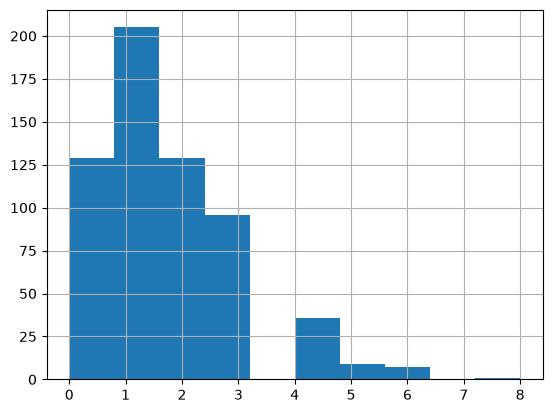

In [78]:
shots["goals"].hist()

<Axes: >

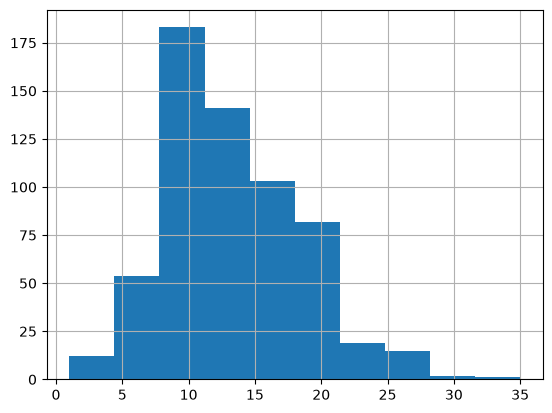

In [79]:
shots["shots"].hist()

<Axes: >

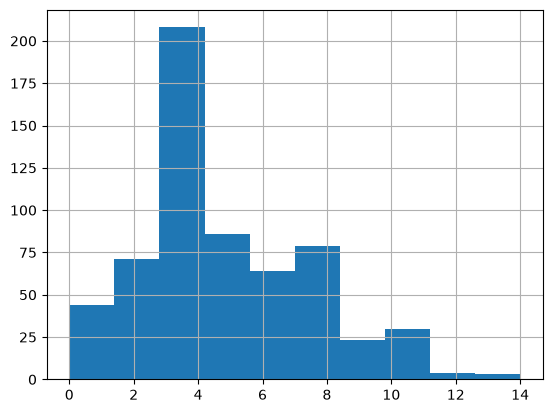

In [80]:
shots["shots_on_target"].hist()

**Relationships**

Text(0, 0.5, 'Goals')

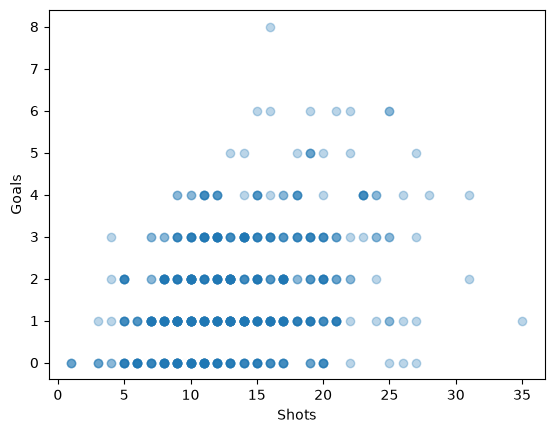

In [81]:
plt.scatter(shots["shots"], shots["goals"], alpha=0.3)
plt.xlabel("Shots")
plt.ylabel("Goals")

Text(0, 0.5, 'Goals')

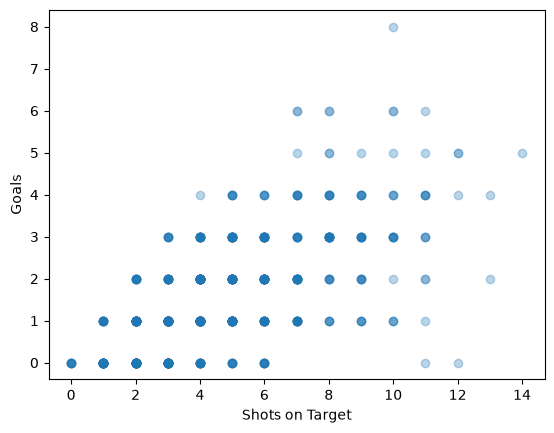

In [82]:
plt.scatter(shots["shots_on_target"], shots["goals"], alpha=0.3)
plt.xlabel("Shots on Target")
plt.ylabel("Goals")

Group same number of shots on target and compute the mean goals by number of shots on target.

In [83]:
grouped = shots.groupby("shots_on_target")
goals_by_sot = grouped["goals"].mean()

goals_by_sot

shots_on_target
0     0.000000
1     0.270270
2     0.690141
3     0.930000
4     1.444444
5     1.837209
6     1.906250
7     2.400000
8     3.088235
9     2.739130
10    3.529412
11    3.153846
12    3.500000
13    3.000000
14    5.000000
Name: goals, dtype: float64

Text(0, 0.5, 'Average Goals')

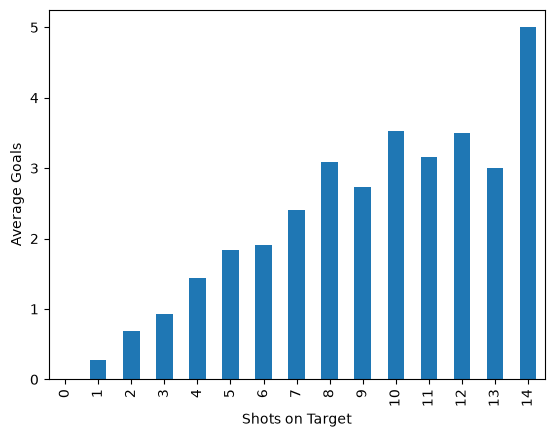

In [84]:
goals_by_sot.plot(kind="bar")
plt.xlabel("Shots on Target")
plt.ylabel("Average Goals")

Group same number of shots and compute the mean of goals by number of shots. 

In [85]:
grouped = shots.groupby("shots")
goals_by_shots = grouped["goals"].mean()
goals_by_shots

shots
1     0.000000
3     0.250000
4     1.200000
5     0.944444
6     0.307692
7     1.000000
8     1.117647
9     1.260870
10    1.444444
11    1.571429
12    1.720000
13    1.469388
14    1.714286
15    1.815789
16    1.838710
17    1.617647
18    2.473684
19    2.200000
20    1.791667
21    2.000000
22    2.714286
23    3.833333
24    2.833333
25    2.857143
26    1.666667
27    2.250000
28    4.000000
31    3.000000
35    1.000000
Name: goals, dtype: float64

Text(0, 0.5, 'Average Goals')

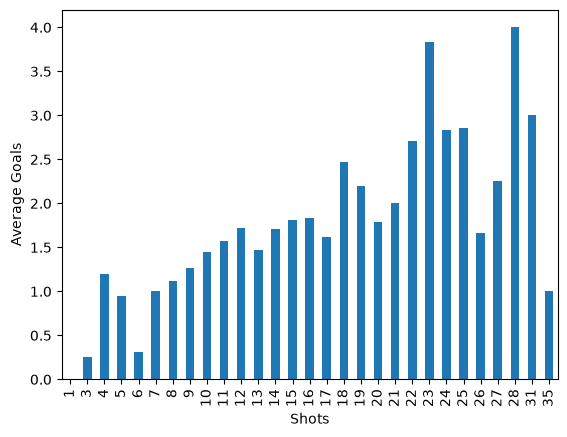

In [86]:
goals_by_shots.plot(kind="bar")
plt.xlabel("Shots")
plt.ylabel("Average Goals")

*Correlations*

In [87]:
shots[["goals", "shots", "shots_on_target"]].corr()

,goals,shots,shots_on_target
goals,1.000000,0.329101,0.630736
shots,0.329101,1.000000,0.676584
shots_on_target,0.630736,0.676584,1.000000


In [105]:
shots["conversion_sot"] = shots["goals"] / shots["shots_on_target"]
shots["conversion_sot"].mean()

np.float64(0.3366934305364057)

In [113]:
shots["conversion_shots"] = shots["goals"] / shots["shots"]
shots["conversion_shots"].mean()

np.float64(0.1269243581102564)

**Result:** Shots on target are more strongly correlated with goals than shots.  

**Home vs. Away**

In [114]:
home = shots[shots["venue"] == "home"]
away = shots[shots["venue"] == "away"]

In [115]:
home[["goals", "shots", "shots_on_target"]].corr()

,goals,shots,shots_on_target
goals,1.000000,0.293075,0.585185
shots,0.293075,1.000000,0.690716
shots_on_target,0.585185,0.690716,1.000000


In [116]:
away[["goals", "shots", "shots_on_target"]].corr()

,goals,shots,shots_on_target
goals,1.000000,0.333823,0.672250
shots,0.333823,1.000000,0.612118
shots_on_target,0.672250,0.612118,1.000000


The relationship between shots on target and goals is stronger for away teams than for home.

In [119]:
venue = shots.groupby("venue")
venue_mean = venue[["goals", "shots", "shots_on_target", "conversion_shots", "conversion_sot"]].mean()
mean = shots[["goals", "shots", "shots_on_target", "conversion_shots", "conversion_sot"]].mean().to_frame().transpose()
print(pd.concat([mean, venue_mean]))

         goals      shots  shots_on_target  conversion_shots  conversion_sot
0     1.617647  13.253268         4.771242          0.126924        0.336693
away  1.457516  11.859477         4.192810          0.126516        0.342837
home  1.777778  14.647059         5.349673          0.127333        0.330651
